<h2>Clustering</h2>

In [2]:
load('.RData')

In [137]:
library(factoextra)
library(tidyverse)
library(NbClust)
library(ggpubr)
library(cluster)

In [7]:
# Observaciones con NA values
df_penguins[!complete.cases(df_penguins), ]

species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
Adelie,Torgersen,NA,NA,NA,NA,NA,2007
Adelie,Torgersen,34.1,18.1,193,3475,NA,2007
Adelie,Torgersen,42.0,20.2,190,4250,NA,2007
Adelie,Torgersen,37.8,17.1,186,3300,NA,2007
Adelie,Torgersen,37.8,17.3,180,3700,NA,2007
Adelie,Dream,37.5,18.9,179,2975,NA,2007
Gentoo,Biscoe,44.5,14.3,216,4100,NA,2007
Gentoo,Biscoe,46.2,14.4,214,4650,NA,2008
Gentoo,Biscoe,47.3,13.8,216,4725,NA,2009


In [49]:
# Utilizamos el dataset con los casos con NA values eliminados
df <- na.omit(df_penguins)
df <- as.data.frame(df)
rownames(df) <- paste0(paste0(paste0(rownames(df), substr(df$species,1,1)), substr(df$island,1,1)), substr(df$sex,1,1))
head(df)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
,<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>
1ATm,Adelie,Torgersen,39.1,18.7,181,3750,male,2007
2ATf,Adelie,Torgersen,39.5,17.4,186,3800,female,2007
3ATf,Adelie,Torgersen,40.3,18.0,195,3250,female,2007
4ATf,Adelie,Torgersen,36.7,19.3,193,3450,female,2007
5ATm,Adelie,Torgersen,39.3,20.6,190,3650,male,2007
6ATf,Adelie,Torgersen,38.9,17.8,181,3625,female,2007


<h4>1. Clustering distancia</h4>

In [118]:
#escalado de los datos
df.sc <- scale(df[, 3:6])
#calculamos distancia euclideana
dist.eucl <- dist(df.sc, method = 'euclidean')
round(as.matrix(dist.eucl)[1:6, 1:6], 2) # Visualizamos solo algunos datos

########### SE SUELE USAR PARA CALCULAR DISTANCIAS IN GENE EXPRESSION
# library("factoextra")
# dist.cor <- get_dist(df.scaled, method = "pearson")

,1ATm,2ATf,3ATf,4ATf,5ATm,6ATf
1ATm,0.00,0.76,1.25,1.08,1.17,0.48
2ATf,0.76,0.00,1.00,1.28,1.66,0.48
3ATf,1.25,1.00,0.00,0.98,1.47,1.14
4ATf,1.08,1.28,0.98,0.00,0.88,1.23
5ATm,1.17,1.66,1.47,0.88,0.00,1.56
6ATf,0.48,0.48,1.14,1.23,1.56,0.00


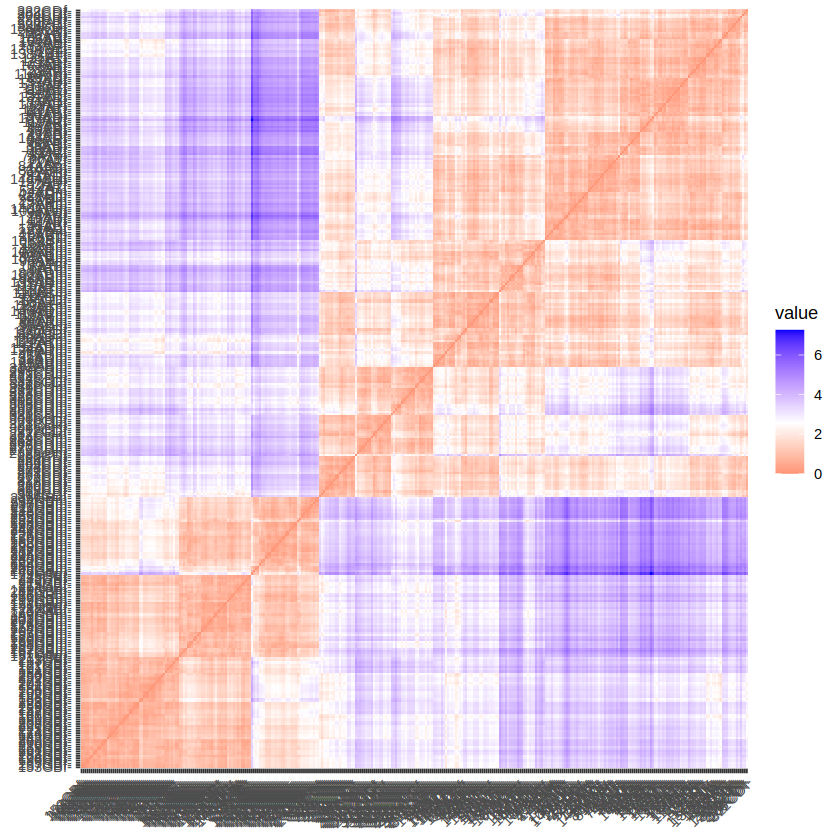

In [51]:
fviz_dist(dist.eucl)
#ROJO alta similitud, AZUL baja similitud

<h4>2. K-means </h4>

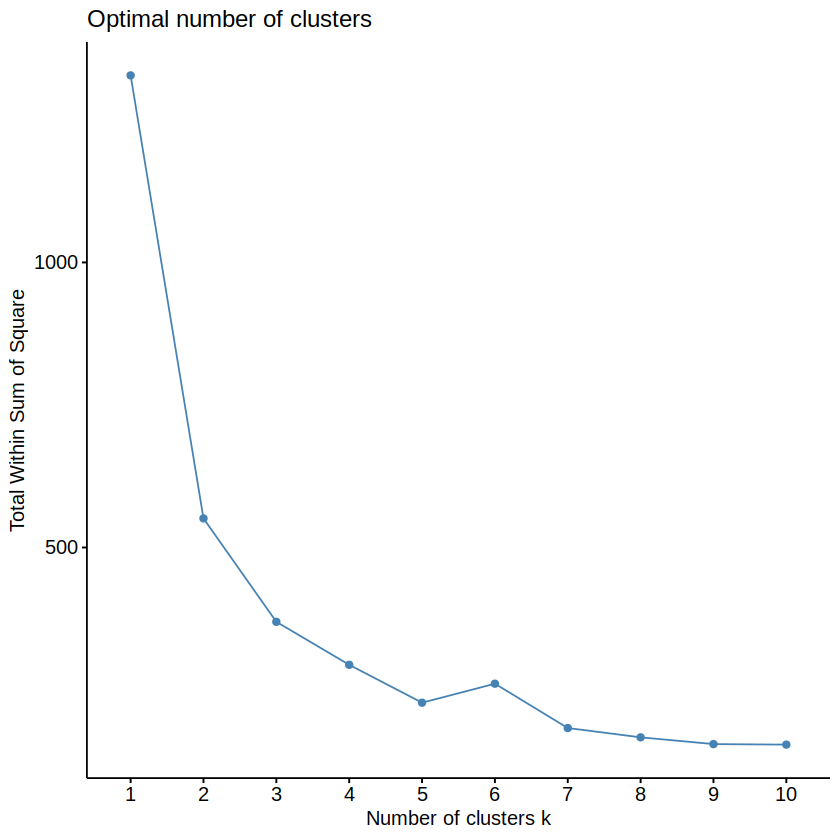

In [52]:
fviz_nbclust(df.sc, kmeans, method = 'wss')

*** : The Hubert index is a graphical method of determining the number of clusters.
                In the plot of Hubert index, we seek a significant knee that corresponds to a 
                significant increase of the value of the measure i.e the significant peak in Hubert
                index second differences plot. 
 


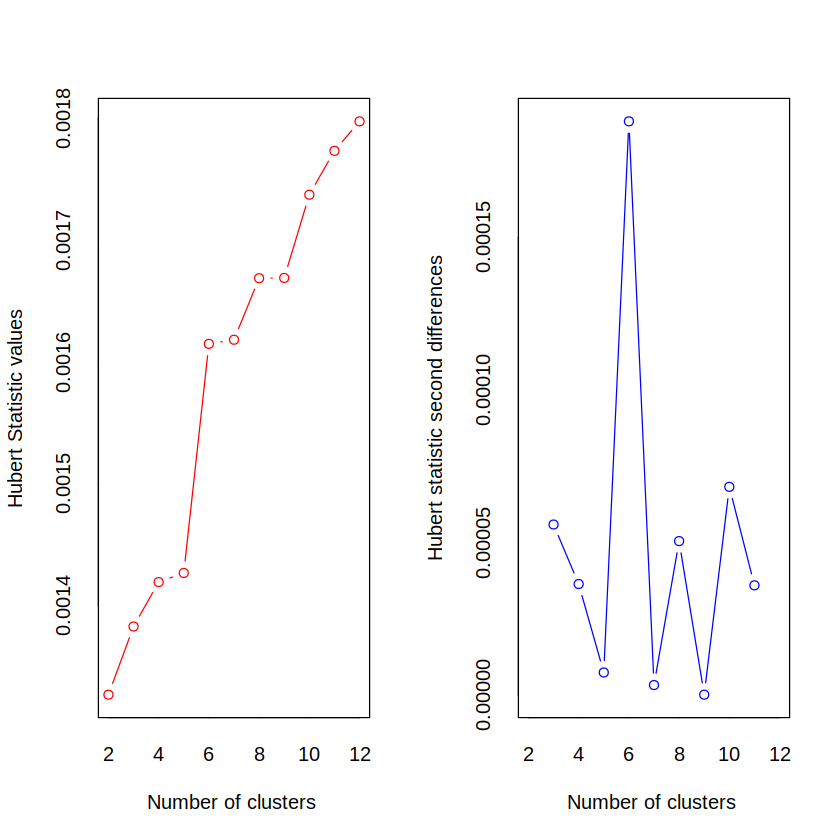

*** : The D index is a graphical method of determining the number of clusters. 
                In the plot of D index, we seek a significant knee (the significant peak in Dindex
                second differences plot) that corresponds to a significant increase of the value of
                the measure. 
 
******************************************************************* 
* Among all indices:                                                
* 9 proposed 2 as the best number of clusters 
* 6 proposed 3 as the best number of clusters 
* 1 proposed 4 as the best number of clusters 
* 1 proposed 5 as the best number of clusters 
* 5 proposed 6 as the best number of clusters 
* 1 proposed 11 as the best number of clusters 
* 1 proposed 12 as the best number of clusters 

                   ***** Conclusion *****                            
 
* According to the majority rule, the best number of clusters is  2 
 
 
******************************************************************* 


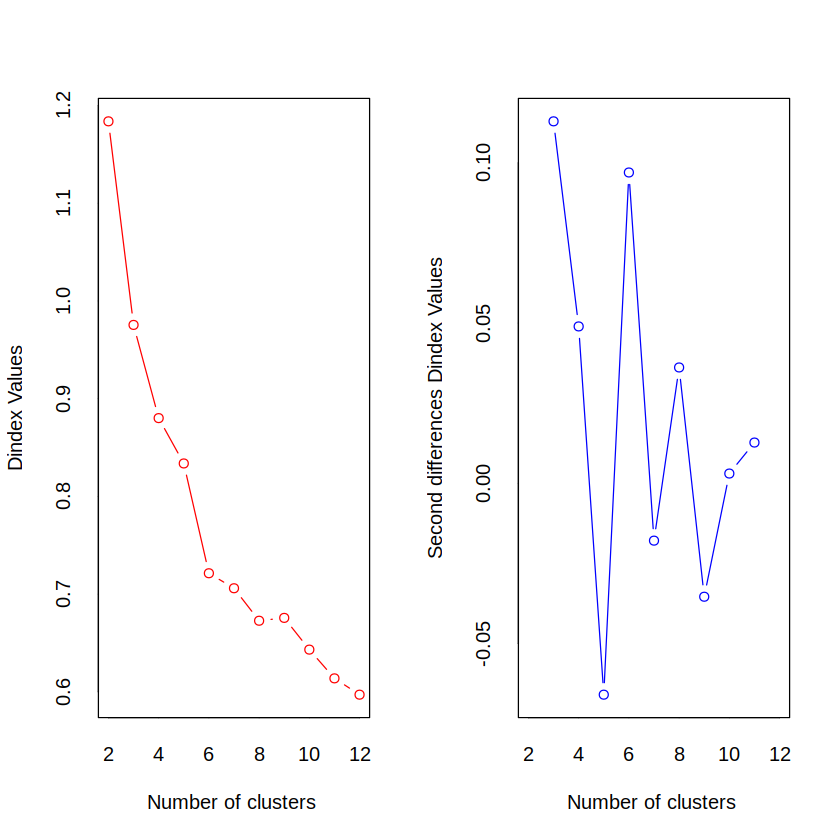

In [53]:
nb <- NbClust(df.sc, distance = 'euclidean', min.nc = 2, max.nc = 12, method = 'kmeans')

# El número de clusters propuestos con mayoria son K = 2, 3, 6

Warning message:
“ggrepel: 295 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


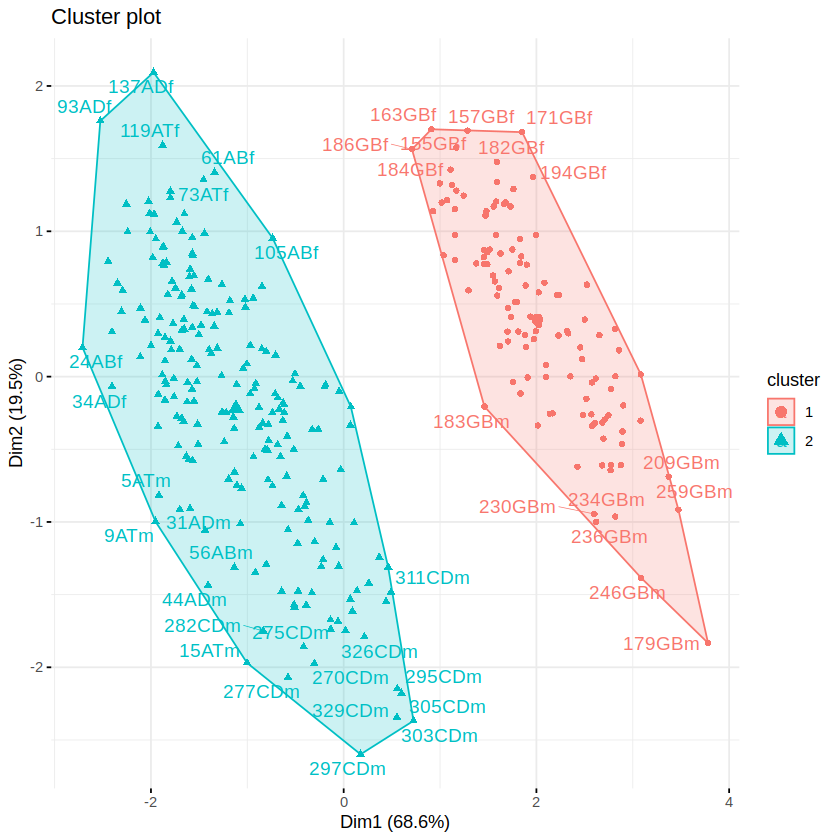

In [56]:
## k = 2
k2 <- kmeans(df.sc, 2, nstart = 25)
fviz_cluster(k2, data = df.sc,
            repel = TRUE, # Avoid label overplotting (slow)
            ggtheme = theme_minimal())

Warning message:
“ggrepel: 295 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


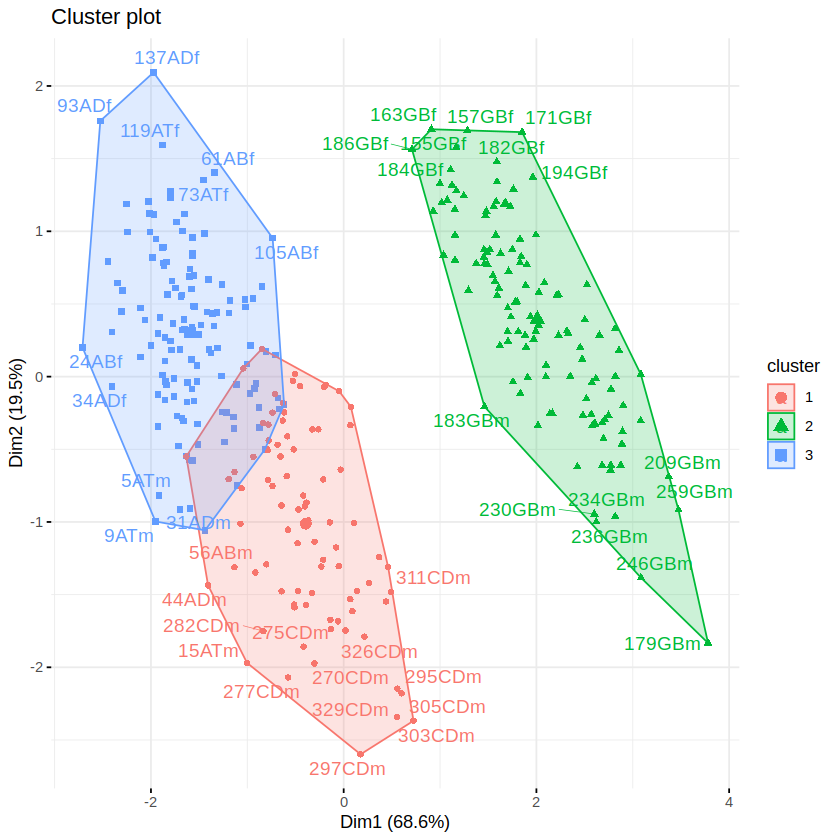

In [57]:
## k = 3
k3 <- kmeans(df.sc, 3, nstart = 25)
fviz_cluster(k3, data = df.sc,
            repel = TRUE, # Avoid label overplotting (slow)
            ggtheme = theme_minimal())

Warning message:
“ggrepel: 295 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


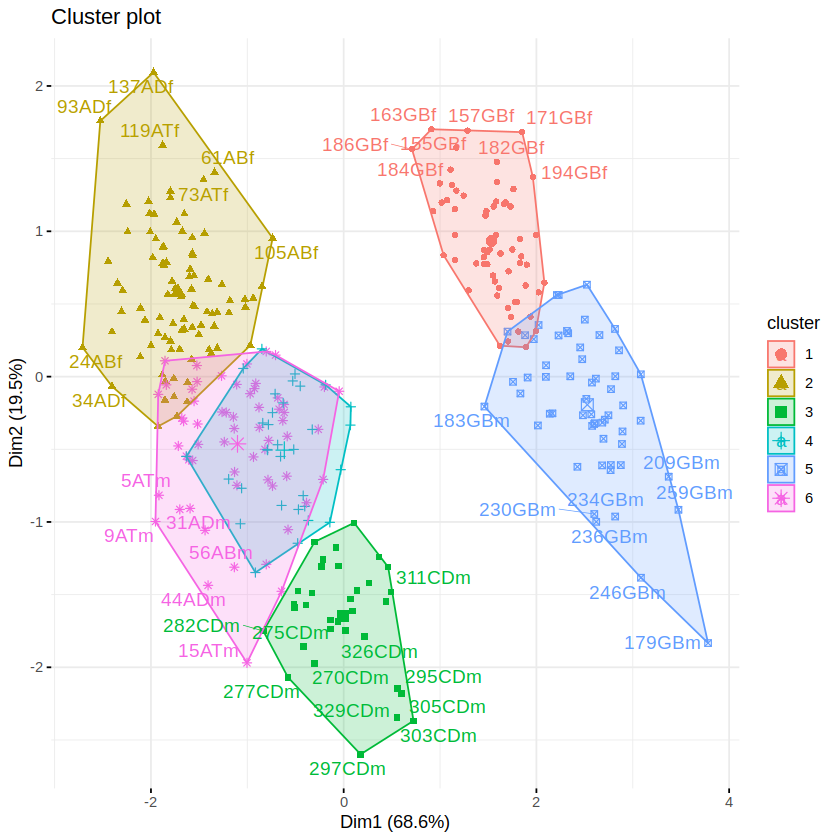

In [66]:
## k = 6
#k6 <- kmeans(df.sc, 6, nstart = 25)
fviz_cluster(k6, data = df.sc,
            repel = TRUE, # Avoid label overplotting (slow)
            ggtheme = theme_minimal())

In [139]:
df_cluster <- cbind(df, data.frame(k2$cluster))
df_cluster <- cbind(df_cluster, data.frame(k3$cluster))
df_cluster <- cbind(df_cluster, data.frame(k6$cluster))
head(df_cluster)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year,k2.cluster,k3.cluster,k6.cluster
,<fct>,<fct>,<dbl>,<dbl>,<int>,<int>,<fct>,<int>,<int>,<int>,<int>
1ATm,Adelie,Torgersen,39.1,18.7,181,3750,male,2007,2,3,2
2ATf,Adelie,Torgersen,39.5,17.4,186,3800,female,2007,2,3,2
3ATf,Adelie,Torgersen,40.3,18.0,195,3250,female,2007,2,3,2
4ATf,Adelie,Torgersen,36.7,19.3,193,3450,female,2007,2,3,2
5ATm,Adelie,Torgersen,39.3,20.6,190,3650,male,2007,2,3,6
6ATf,Adelie,Torgersen,38.9,17.8,181,3625,female,2007,2,3,2


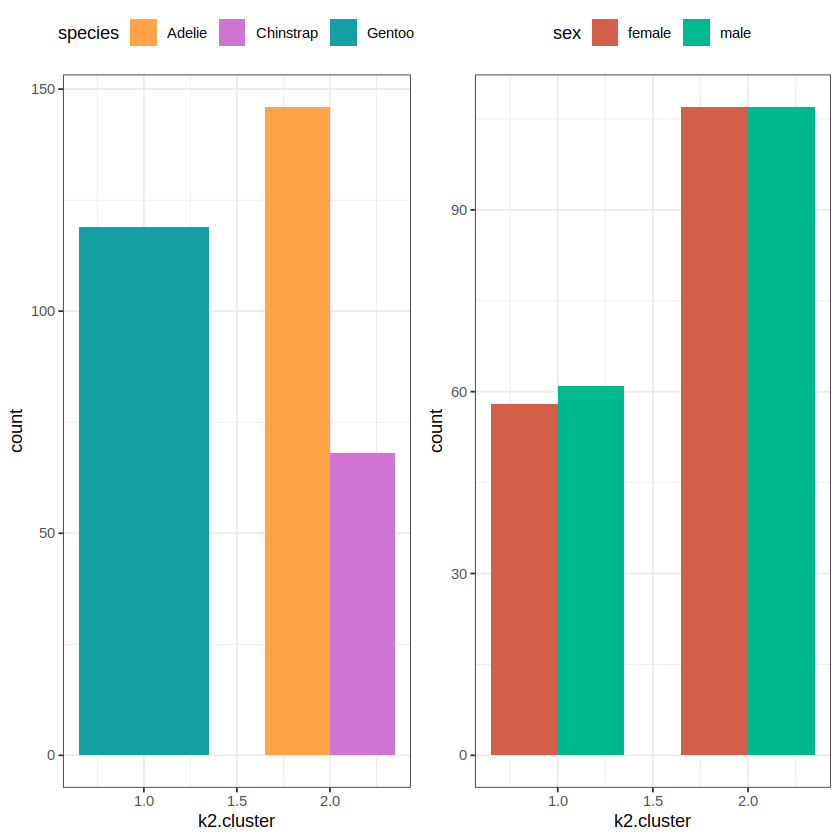

In [161]:
# 2 Clusters

p2 <- ggplot(df_cluster, aes(k2.cluster, fill = species)) +
        geom_bar(stat = 'count', width=0.7, position=position_dodge()) +
        theme_bw() +
        scale_fill_manual(values = penguins_color) +
        theme(legend.position="top")

p2.sex <- ggplot(df_cluster, aes(k2.cluster, fill = sex)) +
        geom_bar(stat = 'count', width=0.7, position=position_dodge()) +
        theme_bw() +
        scale_fill_manual(values = sex_color) +
        theme(legend.position="top")

ggarrange(p2, p2.sex)

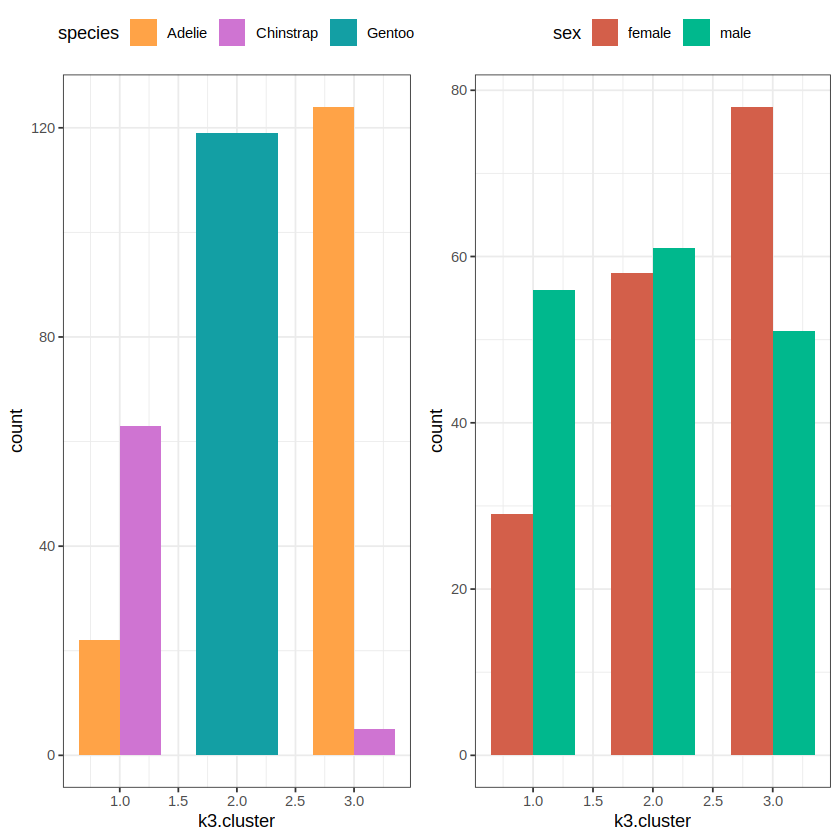

In [162]:
# 3 Clusters
p3 <- ggplot(df_cluster, aes(k3.cluster, fill = species)) +
        geom_bar(stat = 'count', width=0.7, position=position_dodge()) +
        theme_bw() +
        scale_fill_manual(values = penguins_color) +
        theme(legend.position="top")

p3.sex <- ggplot(df_cluster, aes(k3.cluster, fill = sex)) +
        geom_bar(stat = 'count', width=0.7, position=position_dodge()) +
        theme_bw() +
        scale_fill_manual(values = sex_color) +
        theme(legend.position="top")

ggarrange(p3, p3.sex)

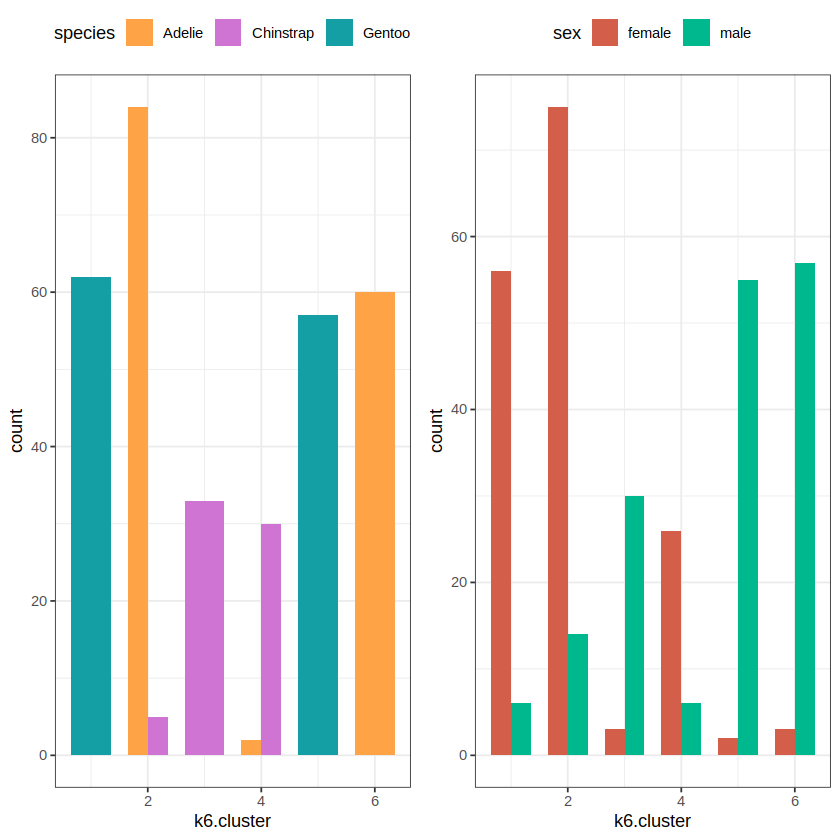

In [163]:
# 6 Clusters
p6 <- ggplot(df_cluster, aes(k6.cluster, fill = species)) +
        geom_bar(stat = 'count', width=0.7, position=position_dodge()) +
        theme_bw() +
        scale_fill_manual(values = penguins_color) +
        theme(legend.position="top")

p6.sex <- ggplot(df_cluster, aes(k6.cluster, fill = sex)) +
        geom_bar(stat = 'count', width=0.7, position=position_dodge()) +
        theme_bw() +
        scale_fill_manual(values = sex_color) +
        theme(legend.position="top")

ggarrange(p6, p6.sex)

<h4>3. K-Medoids </h4>
K-means es muy sessible a outliers, K-medoids es más robusto

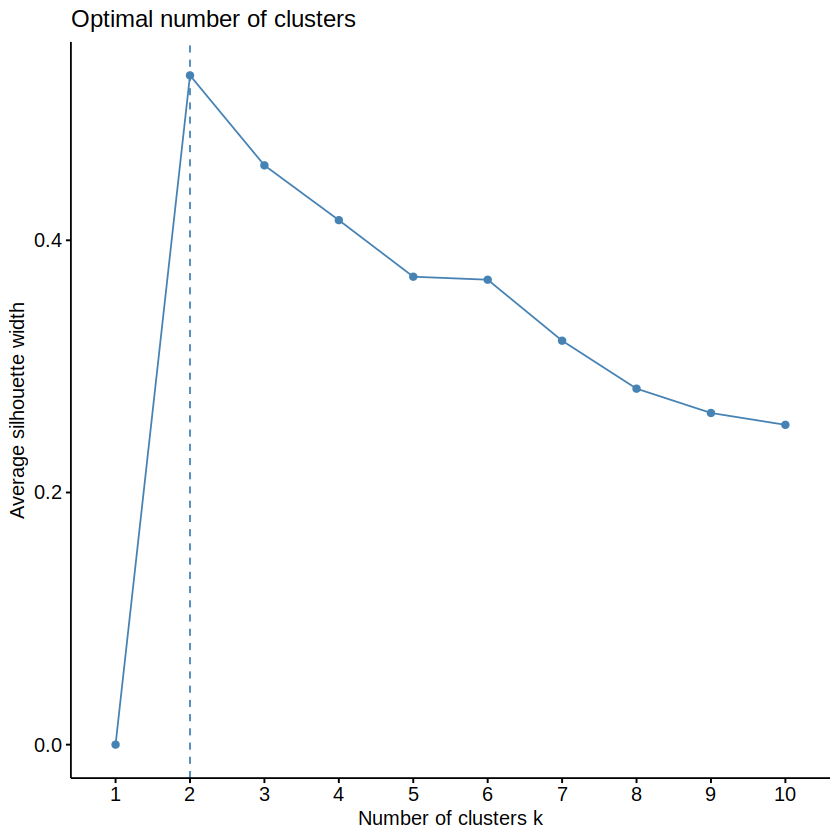

In [121]:
fviz_nbclust(df.sc, pam, method = 'silhouette')

Warning message:
“ggrepel: 295 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


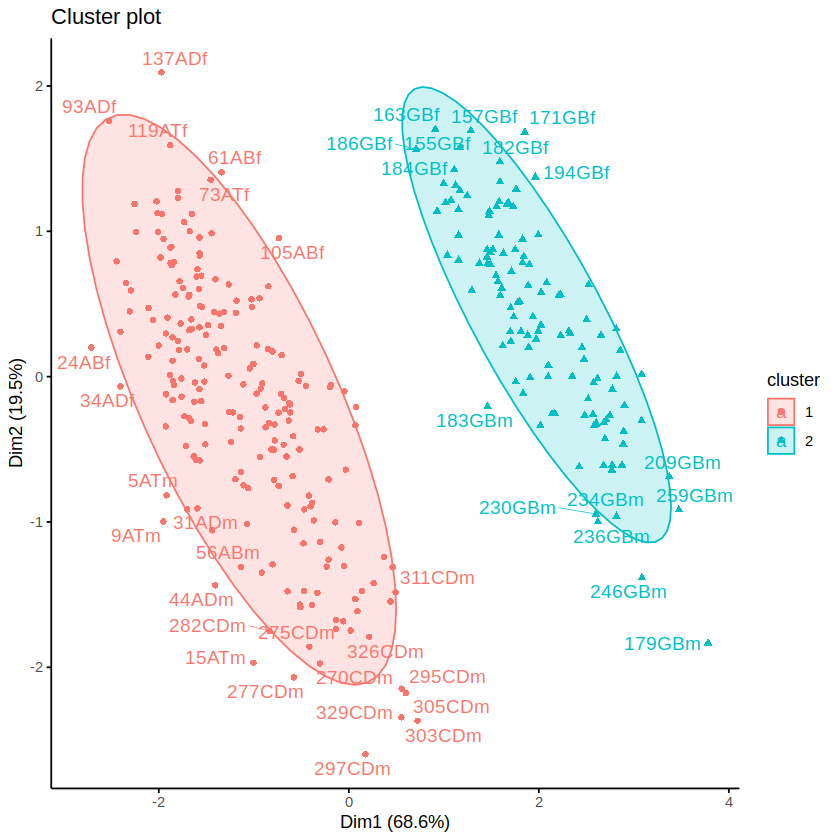

In [124]:
pam2 <- pam(df.sc, 2)
fviz_cluster(pam2,
    ellipse.type = "t", 
    repel = TRUE, 
    ggtheme = theme_classic()
)

Warning message:
“ggrepel: 296 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


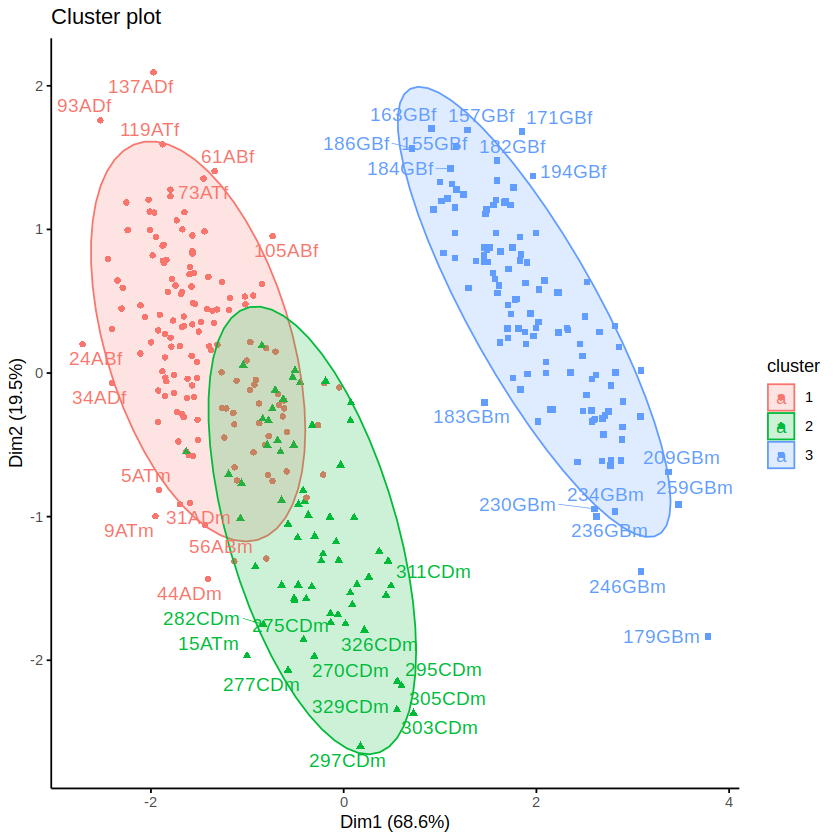

In [125]:
pam3 <- pam(df.sc, 3)
fviz_cluster(pam3,
    ellipse.type = "t", 
    repel = TRUE, 
    ggtheme = theme_classic()
)

Warning message:
“ggrepel: 295 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


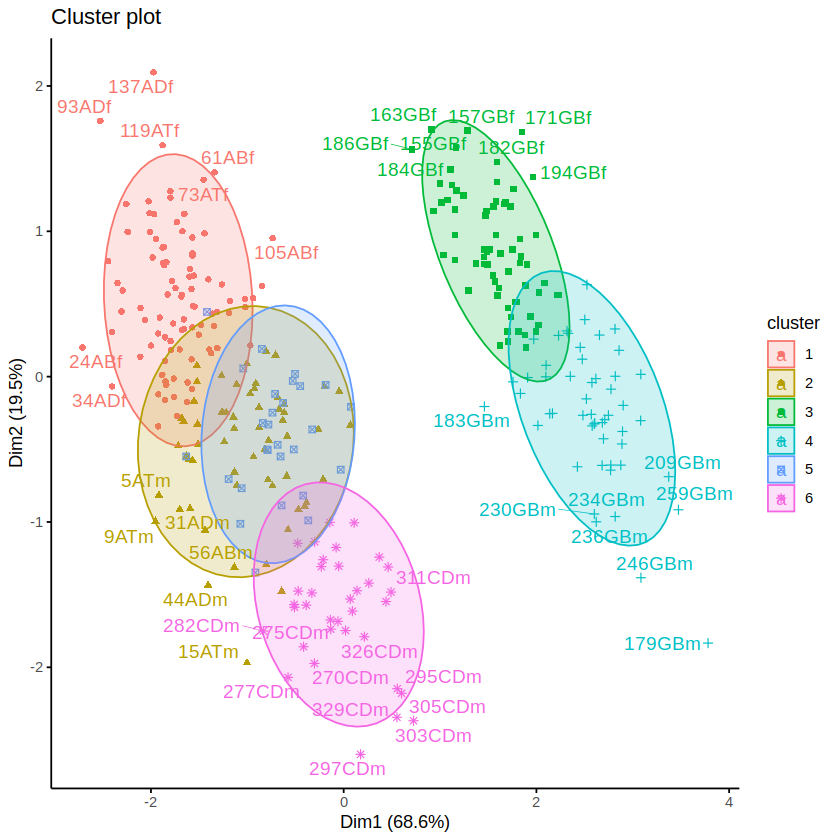

In [126]:
pam6 <- pam(df.sc, 6)
fviz_cluster(pam6,
    ellipse.type = "t", 
    repel = TRUE, 
    ggtheme = theme_classic()
)

In [150]:
# df_cluster <- cbind(df_cluster, pam2$clustering)
# df_cluster <- cbind(df_cluster, pam3$clustering)
# df_cluster <- cbind(df_cluster, pam6$clustering)
# names(df_cluster)[12] <- 'p2.cluster'
# names(df_cluster)[13] <- 'p3.cluster'
# names(df_cluster)[14] <- 'p6.cluster'
head(df_cluster[, -c(2:6, 8)])

,species,sex,k2.cluster,k3.cluster,k6.cluster,p2.cluster,p3.cluster,p6.cluster
,<fct>,<fct>,<int>,<int>,<int>,<int>,<int>,<int>
1ATm,Adelie,male,2,3,2,1,1,1
2ATf,Adelie,female,2,3,2,1,1,1
3ATf,Adelie,female,2,3,2,1,1,1
4ATf,Adelie,female,2,3,2,1,1,1
5ATm,Adelie,male,2,3,6,1,1,2
6ATf,Adelie,female,2,3,2,1,1,1


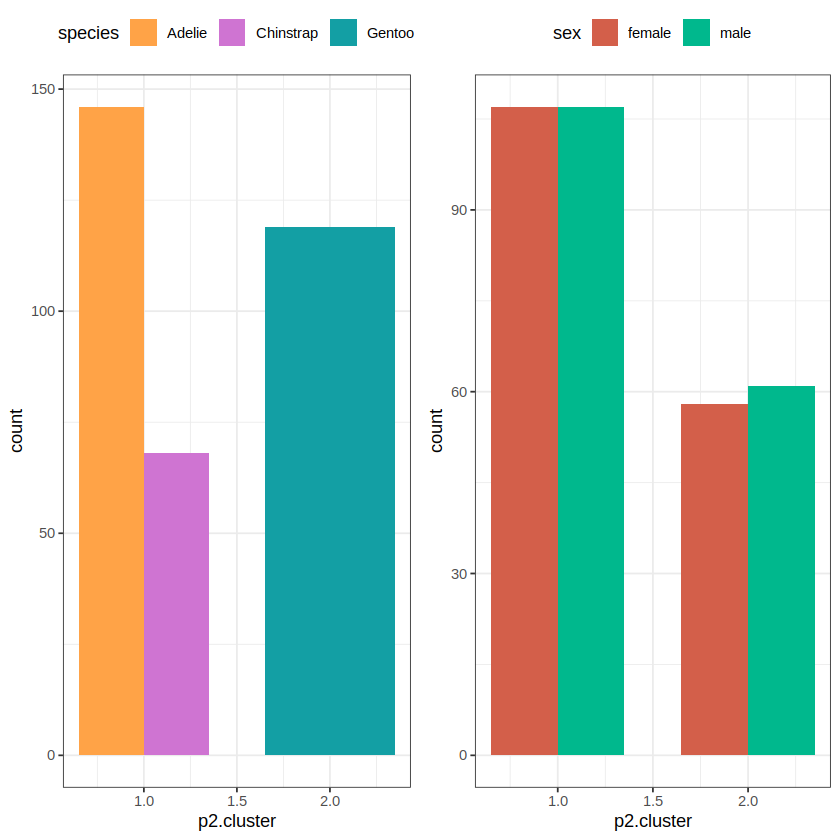

In [164]:
pa2 <- ggplot(df_cluster, aes(p2.cluster, fill = species)) +
        geom_bar(stat = 'count', width=0.7, position=position_dodge()) +
        theme_bw() +
        scale_fill_manual(values = penguins_color) +
        theme(legend.position="top")

pa2.sex <- ggplot(df_cluster, aes(p2.cluster, fill = sex)) +
        geom_bar(stat = 'count', width=0.7, position=position_dodge()) +
        theme_bw() +
        scale_fill_manual(values = sex_color) +
        theme(legend.position="top")

ggarrange(pa2, pa2.sex)

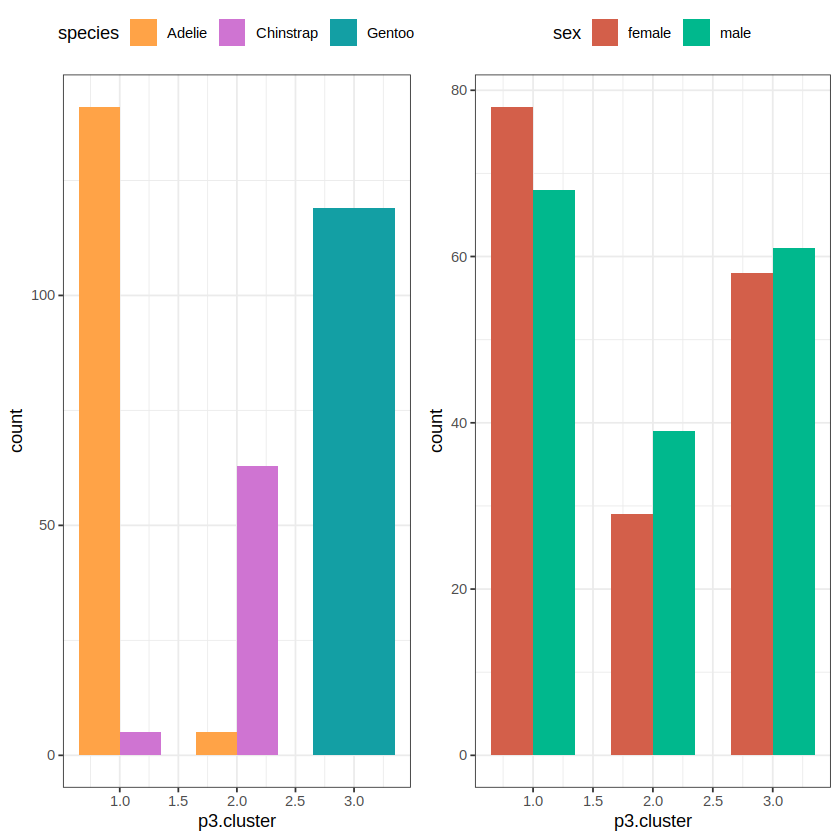

In [165]:
pa3 <- ggplot(df_cluster, aes(p3.cluster, fill = species)) +
        geom_bar(stat = 'count', width=0.7, position=position_dodge()) +
        theme_bw() +
        scale_fill_manual(values = penguins_color) +
        theme(legend.position="top")

pa3.sex <- ggplot(df_cluster, aes(p3.cluster, fill = sex)) +
        geom_bar(stat = 'count', width=0.7, position=position_dodge()) +
        theme_bw() +
        scale_fill_manual(values = sex_color) +
        theme(legend.position="top")

ggarrange(pa3, pa3.sex)

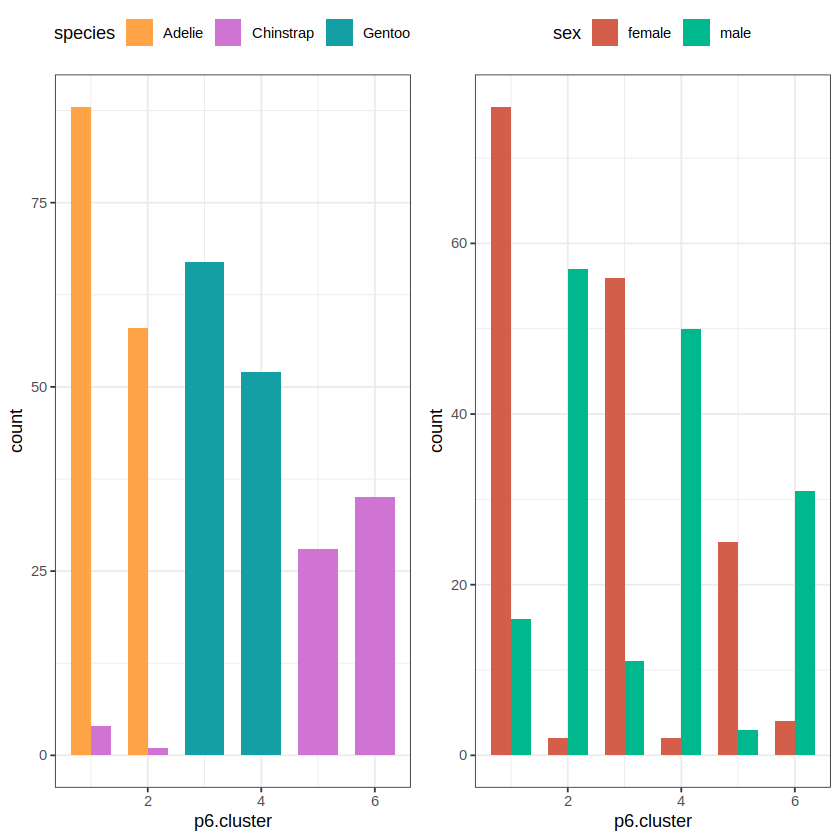

In [166]:
pa6 <- ggplot(df_cluster, aes(p6.cluster, fill = species)) +
        geom_bar(stat = 'count', width=0.7, position=position_dodge()) +
        theme_bw() +
        scale_fill_manual(values = penguins_color) +
        theme(legend.position="top")

pa6.sex <- ggplot(df_cluster, aes(p6.cluster, fill = sex)) +
        geom_bar(stat = 'count', width=0.7, position=position_dodge()) +
        theme_bw() +
        scale_fill_manual(values = sex_color) +
        theme(legend.position="top")

ggarrange(pa6, pa6.sex)

<h4>4. Comparacion k-means vs k-medoids </h4>

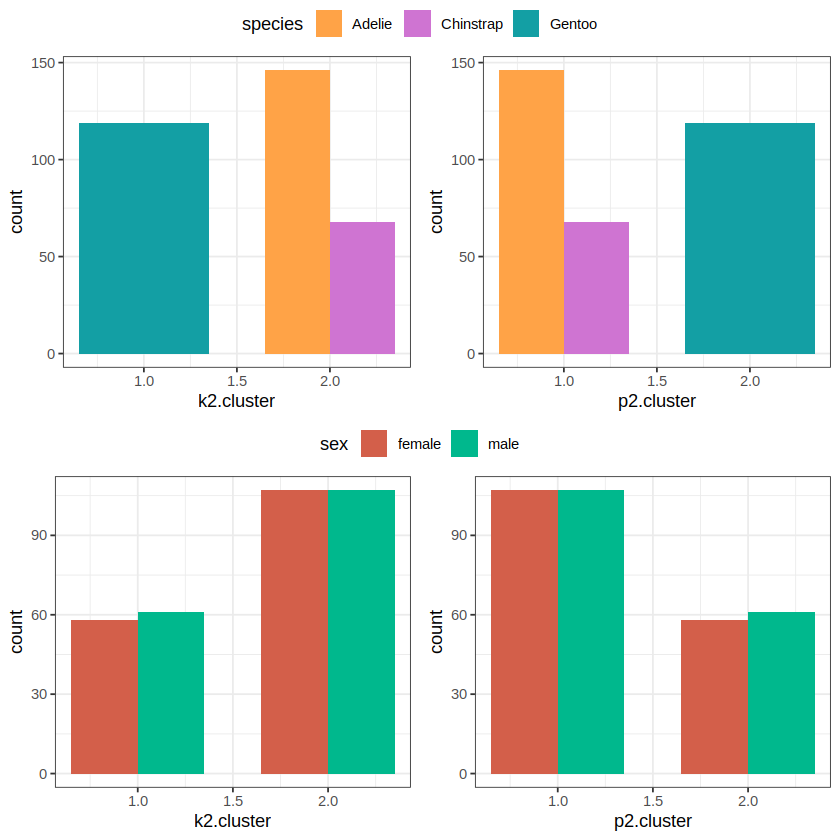

In [167]:
# 2 clusters
ggarrange(
    ggarrange(p2, pa2, common.legend = TRUE, legend="top"),
    ggarrange(p2.sex, pa2.sex, common.legend = TRUE, legend="top"),
    nrow = 2, ncol = 1
)


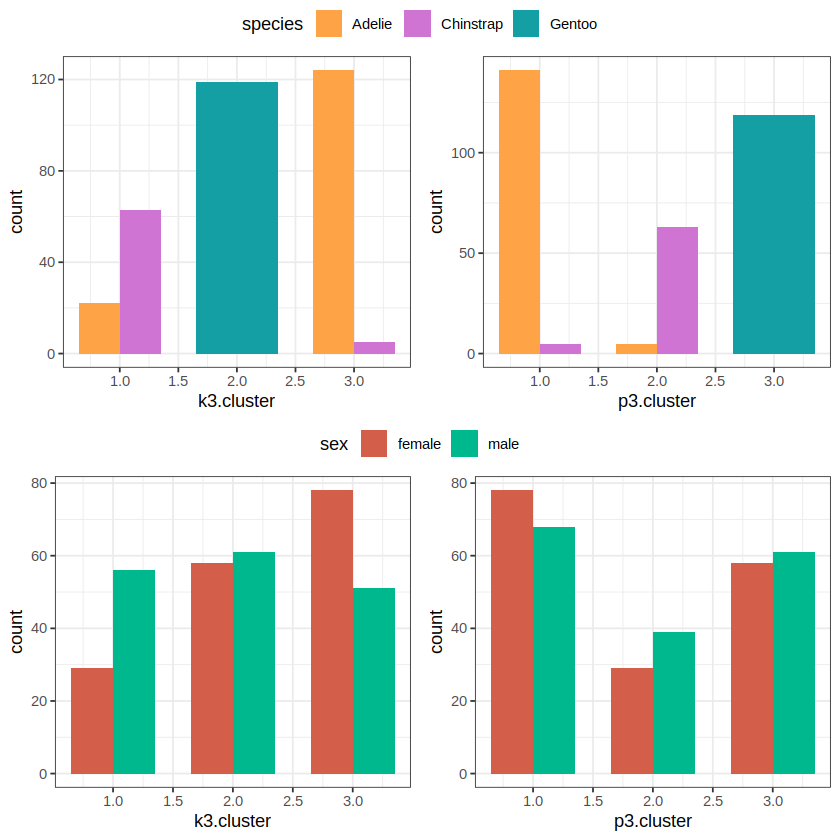

In [168]:
# 3 clusters
ggarrange(
    ggarrange(p3, pa3, common.legend = TRUE, legend="top"),
    ggarrange(p3.sex, pa3.sex, common.legend = TRUE, legend="top"),
    nrow = 2, ncol = 1
)


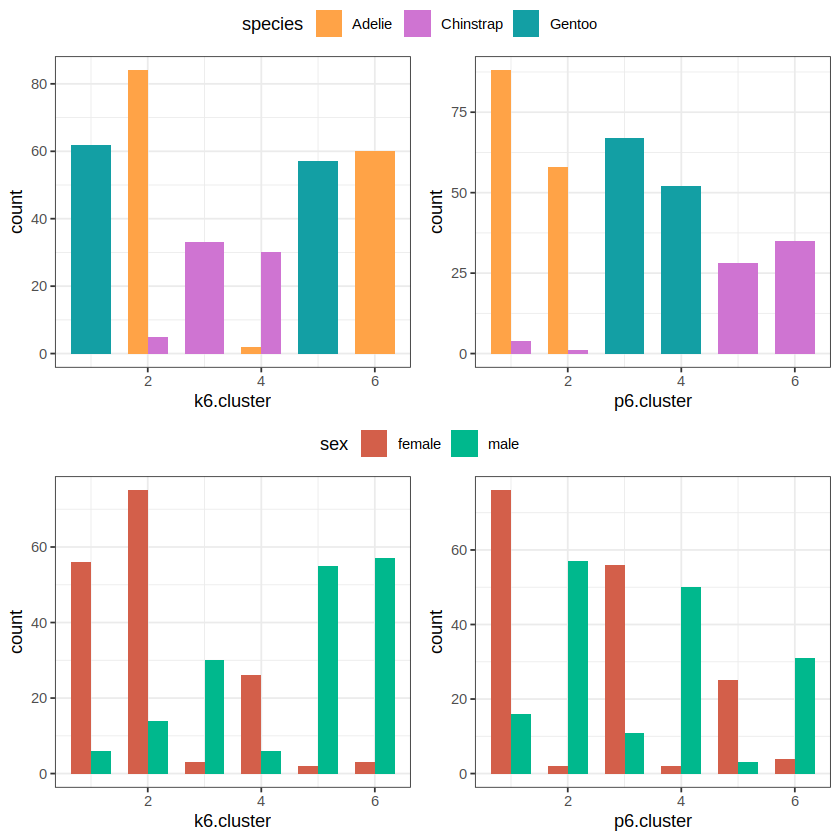

In [169]:
# 6 clusters
ggarrange(
    ggarrange(p6, pa6, common.legend = TRUE, legend="top"),
    ggarrange(p6.sex, pa6.sex, common.legend = TRUE, legend="top"),
    nrow = 2, ncol = 1
)


In [171]:
# PONER A LOS GRAFICOS LA MISMA ESCALA!!!!!!!!!!!!!!

In [117]:
save.image()